# ML Week 15: Classification

Source: https://github.com/RafayKhattak/Digit-Classification-Pytorch/blob/main/DigitClassificationPytorch.ipynb

In [1]:
%pip install torchvision

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ------------ --------------------------- 1.3/4.3 MB 8.6 MB/s eta 0:00:01
   ------------------------------- -------- 3.4/4.3 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 8.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importing dependencies
import torch
from PIL import Image
from torch import nn,save,load
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [47]:
# Loading Data
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="data", download=True, train=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [25]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train

In [32]:
import matplotlib.pyplot as plt
import numpy as np

print(train_dataset[0][1])
digit = np.array(train_dataset[0][0])


5


In [33]:
digit.shape

(28, 28)

In [34]:
# Define the image classifier model
class ImageClassifier(nn.Module):
    def __init__(self):
        super(ImageClassifier, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU()
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 22 * 22, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [50]:
# Create an instance of the image classifier model
device = torch.device("cpu")
classifier = ImageClassifier().to(device)

In [51]:
# Define the optimizer and loss function
optimizer = Adam(classifier.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [52]:
# Train the model
for epoch in range(10):  # Train for 10 epochs
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()  # Reset gradients
        outputs = classifier(images)  # Forward pass
        loss = loss_fn(outputs, labels)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

    print(f"Epoch:{epoch} loss is {loss.item()}")



Epoch:0 loss is 0.22961421310901642
Epoch:1 loss is 0.0005742576904594898
Epoch:2 loss is 0.07169028371572495
Epoch:3 loss is 0.002702370984479785
Epoch:4 loss is 0.0007335190894082189
Epoch:5 loss is 0.0002572373196016997
Epoch:6 loss is 0.0003071376122534275
Epoch:7 loss is 0.00615081749856472
Epoch:8 loss is 0.001481426414102316
Epoch:9 loss is 0.004794820677489042


### Classification with pretrained ResNet50

Source: https://docs.pytorch.org/vision/main/models.html

In [ ]:
# Save the trained model
torch.save(classifier.state_dict(), 'model_state.pt')

In [ ]:
# Load the saved model
with open('model_state.pt', 'rb') as f: 
     classifier.load_state_dict(load(f))

In [ ]:
# Perform inference on an image
img = Image.open('image.jpg')
img_transform = transforms.Compose([transforms.ToTensor()])
img_tensor = img_transform(img).unsqueeze(0).to(device)
output = classifier(img_tensor)
predicted_label = torch.argmax(output)
print(f"Predicted label: {predicted_label}")



In [9]:
from torchvision.io import decode_image
from torchvision.models import resnet152, ResNet152_Weights

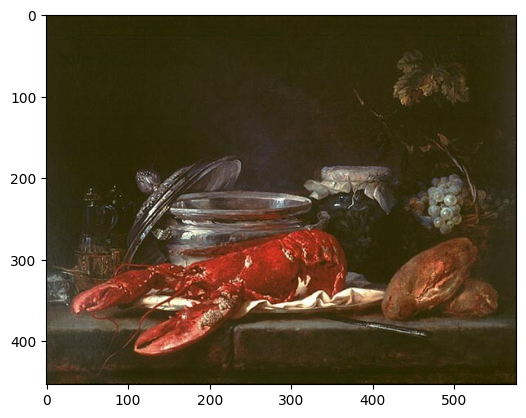

In [28]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("delacroix1.jpg")[:,:,::-1]
plt.imshow(img)

In [30]:
img = decode_image("delacroix1.jpg")

In [10]:
# Step 1: Initialize model with the best available weights
weights = ResNet152_Weights.DEFAULT
model = resnet152(weights=weights)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to C:\Users\re72fam/.cache\torch\hub\checkpoints\resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:15<00:00, 15.8MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [11]:
# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

In [12]:
# Step 3: Apply inference preprocessing transforms
batch = preprocess(img).unsqueeze(0)

In [14]:
# Step 4: Use the model and print the predicted category
prediction = model(batch).squeeze(0).softmax(0)
class_id = prediction.argmax().item()
score = prediction[class_id].item()
category_name = weights.meta["categories"][class_id]
print(f"{category_name}: {100 * score:.1f}%")

American lobster: 81.4%


Note: If you're doing massive amounts of images, you can use ResNet50 for speed. However, accuracy will slightly drop (the lobster probability with ResNet50 is 9%)